# Debugging and Tracing LangGraph
- Notebook by Adam Lang
- Date: 8/10/2026

# Overview
- In this notebook we will walk through basic debugging and tracing of LangGraph using LangSmith and LangGraph studio.

## Imports

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import END, START
from langgraph.graph.state import StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage

## basic imports
import os
from dotenv import load_dotenv

## init load_dotenv()
load_dotenv()



True

## Set LANGSMITH_PROJECT
- docs: https://docs.langchain.com/langsmith/log-traces-to-project#set-the-destination-project-statically

In [2]:
os.environ["LANGSMITH_PROJECT"]="TestProject"

## Set Environment Variables
- see docs: https://docs.langchain.com/langsmith/observability-quickstart

In [3]:
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGSMITH_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGSMITH_TRACING"]="true"

In [4]:
## init llm from groq models
from langchain.chat_models import init_chat_model
llm=init_chat_model("groq:llama-3.3-70b-versatile")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x1124fd550>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1124fe270>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

# Create Graph with Tool Call

In [5]:
## create State class
class State(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages] ## add_messages is the reducer (concatenates all messages)
    

In [6]:
## graph with tool
from langchain_core.tools import tool

@tool
def add(a:float,b:float):
    """Add two numbers"""
    return a+b

tools=[add] ## define tool
tool_node=ToolNode([add]) ## tool node


## bind LLM with tool
llm_with_tool=llm.bind_tools([add])

## func to call llm model
def call_llm_model(state:State):
    return {"messages":[llm_with_tool.invoke(state['messages'])]} ## invoke --> save back to messages


## Create State Graph

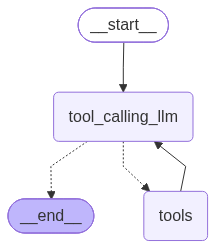

In [7]:
## Stategraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def call_llm_model(state:State):
    return {"messages":[llm_with_tool.invoke(state['messages'])]} ## invoke --> save back to messages

## build graph
builder=StateGraph(State) #1 create state
builder.add_node("tool_calling_llm", call_llm_model)
builder.add_node("tools", ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # if latest message (result) from assistant is not a tool call --> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm") ## instead of END, send to tool_calling_llm

## compile the graph
graph=builder.compile()

## display
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
## invoke test #1
response=graph.invoke({"messages":"What is machine learning?"})

In [9]:
response

{'messages': [HumanMessage(content='What is machine learning?', additional_kwargs={}, response_metadata={}, id='a51b43ef-2083-446e-b84d-3f26dccb6390'),
  AIMessage(content='Machine learning is a subset of artificial intelligence that involves the use of algorithms and statistical models to enable machines to learn from data, make decisions, and improve their performance over time without being explicitly programmed. It allows systems to automatically improve their performance on a task by learning from experience, much like humans do. Machine learning is widely used in applications such as image and speech recognition, natural language processing, predictive analytics, and decision-making systems.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 87, 'prompt_tokens': 217, 'total_tokens': 304, 'completion_time': 0.329770056, 'completion_tokens_details': None, 'prompt_time': 0.023502252, 'prompt_tokens_details': None, 'queue_time': 0.082914171, 'total_time':

In [10]:
## invoke test #2
response=graph.invoke({"messages":"What is 5 plus 20?"})

In [11]:
response

{'messages': [HumanMessage(content='What is 5 plus 20?', additional_kwargs={}, response_metadata={}, id='fa93a782-661d-45cd-b3c5-fe1560d0fefc'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'x4ethctqp', 'function': {'arguments': '{"a":5,"b":20}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 220, 'total_tokens': 238, 'completion_time': 0.050437518, 'completion_tokens_details': None, 'prompt_time': 0.074691077, 'prompt_tokens_details': None, 'queue_time': 0.066514733, 'total_time': 0.125128595}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ff0dc-2af1-7591-b9fd-ed023ba343d4-0', tool_calls=[{'name': 'add', 'args': {'a': 5, 'b': 20}, 'id': 'x4ethctqp', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 220, 'output_tokens'